# 14장 실습 ① — 오토인코더로는 왜 생성이 안 되는가

**TensorFlow 판**

13장의 디코더에 **난수를 넣어** 봅니다. 숫자가 나올까요.

## 14.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 14.1 데이터와 지표

**다양성 지표**를 먼저 정의합니다. 생성물끼리 얼마나 다른지 재는 값입니다.
모드 붕괴를 눈이 아니라 **숫자로** 보기 위해서입니다.

In [3]:
LATENT = 32

s = data.mnist()
x_train = s.x_train.reshape(-1, 784) * 2 - 1     # tanh 출력에 맞춰 [-1, 1]
print(f"학습 {x_train.shape}, 범위 [{x_train.min():.0f}, {x_train.max():.0f}]")

def show(rows, titles, n=8):
    fig, axes = plt.subplots(len(rows), n, figsize=(1.15 * n, 1.25 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (imgs, t) in enumerate(zip(rows, titles)):
        for c in range(n):
            axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray", vmin=-1, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        axes[r, 0].set_ylabel(t, fontsize=9)
    plt.tight_layout(); plt.show()

def diversity(A, n=300, seed=1):
    """생성물끼리의 평균 거리. **모드 붕괴를 재는 가장 간단한 지표.**

    다 비슷하게 생겼으면 이 값이 작아진다.
    """
    idx = np.random.default_rng(seed).choice(len(A), min(n, len(A)), replace=False)
    B = A[idx]
    d = np.sqrt(((B[:, None, :] - B[None, :, :]) ** 2).sum(-1))
    return float(d[np.triu_indices(len(B), 1)].mean())

REAL_DIV = diversity(x_train[:2000])
print(f"진짜 숫자끼리의 평균 거리 {REAL_DIV:.3f}  ← 이것이 목표치입니다")
dlbook.record("ch14_real_diversity", REAL_DIV)

학습 (54000, 784), 범위 [-1, 1]


진짜 숫자끼리의 평균 거리 20.289  ← 이것이 목표치입니다
ch14_real_diversity = 20.2895


20.28948402404785

## 14.2 모델과 학습 루프 — 여기만 판마다 다릅니다

**세 판의 차이가 이 장에서 가장 큽니다.**

| 판 | 방식 |
|---|---|
| Keras 3 | `keras.Model` 을 상속해 `train_step` 만 다시 씁니다 |
| TensorFlow | `tf.function` + `GradientTape` 를 직접 씁니다 |
| PyTorch | 걸음마다 손으로 씁니다 — **가장 훤히 보입니다** |

GAN처럼 **한 걸음에 두 모델을 번갈아 갱신**해야 하는 경우,
`fit()` 한 줄로는 안 됩니다.

In [4]:
import tensorflow as tf

L_ = tf.keras.layers

def make_generator(latent):
    return tf.keras.Sequential([
        L_.Input(shape=(latent,)),
        L_.Dense(128, activation="relu"),
        L_.Dense(256, activation="relu"),
        L_.Dense(784, activation="tanh")], name="generator")

def make_discriminator():
    return tf.keras.Sequential([
        L_.Input(shape=(784,)),
        L_.Dense(256, activation="leaky_relu"),
        L_.Dense(128, activation="leaky_relu"),
        L_.Dense(1)], name="discriminator")

def train_gan(x, latent, epochs=30, checkpoints=(1, 5, 30),
              lr=2e-4, batch=128, seed=42, diversity_fn=None):
    """TensorFlow 의 방식 — tf.function 과 GradientTape 를 직접 씁니다."""
    dlbook.set_seed(seed)
    G, D = make_generator(latent), make_discriminator()
    g_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)
    d_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def step(real):
        n = tf.shape(real)[0]
        # ① 판별기
        z = tf.random.normal((n, latent))
        with tf.GradientTape() as tape:
            fake = G(z, training=True)
            dl = (bce(tf.ones_like(D(real, training=True)), D(real, training=True))
                  + bce(tf.zeros_like(D(fake, training=True)), D(fake, training=True)))
        d_opt.apply_gradients(zip(tape.gradient(dl, D.trainable_weights),
                                  D.trainable_weights))
        # ② 생성기
        z = tf.random.normal((n, latent))
        with tf.GradientTape() as tape:
            out = D(G(z, training=True), training=True)
            gl = bce(tf.ones_like(out), out)
        g_opt.apply_gradients(zip(tape.gradient(gl, G.trainable_weights),
                                  G.trainable_weights))
        return dl, gl

    ds = (tf.data.Dataset.from_tensor_slices(x).shuffle(4096)
          .batch(batch, drop_remainder=True))
    z_fix = np.random.default_rng(0).normal(size=(500, latent)).astype("float32")
    hist = []
    for e in range(1, epochs + 1):
        dls, gls = [], []
        for real in ds:
            d_, g_ = step(real); dls.append(float(d_)); gls.append(float(g_))
        if e in checkpoints:
            div = diversity_fn(generate(G, z_fix)) if diversity_fn else 0.0
            hist.append((e, float(np.mean(dls)), float(np.mean(gls)), div))
    return G, D, hist

def generate(G, z):
    return np.asarray(G.predict(z, verbose=0))

def train_autoencoder(x, latent, epochs=15, seed=42):
    dlbook.set_seed(seed)
    enc = tf.keras.Sequential([L_.Input(shape=(784,)),
                               L_.Dense(128, activation="relu"),
                               L_.Dense(latent, activation="relu")])
    dec = tf.keras.Sequential([L_.Input(shape=(latent,)),
                               L_.Dense(128, activation="relu"),
                               L_.Dense(784, activation="tanh")])
    ae = tf.keras.Sequential([enc, dec])
    ae.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse")
    ae.fit(x, x, epochs=dlbook.smoke.epochs(epochs), batch_size=256, verbose=0)
    return enc, dec

def encode(enc, x):
    return np.asarray(enc.predict(x, verbose=0))

def decode(dec, z):
    return np.asarray(dec.predict(z, verbose=0))

## 14.3 오토인코더의 디코더에 난수를 넣으면

학습 데이터가 실제로 만든 잠재 벡터의 분포 —
  평균 7.472   표준편차 6.839   0인 성분의 비율 0.283

★ **표준정규분포가 전혀 아닙니다.** ReLU라 음수가 없고, 평균이 7 넘습니다.
  그런데 '생성'을 하려면 어떤 분포에서 뽑아야 하는지 알아야 합니다.
  **오토인코더는 그것을 알려 주지 않습니다.**

무엇을 디코더에 넣었나                           생성물끼리 평균 거리
----------------------------------------------------


표준정규분포 난수                                   11.163
실제 데이터의 잠재 벡터                               18.589
(진짜 숫자)                                     20.289


ch14_ae_random_diversity = 11.1631
ch14_ae_real_diversity = 18.5886


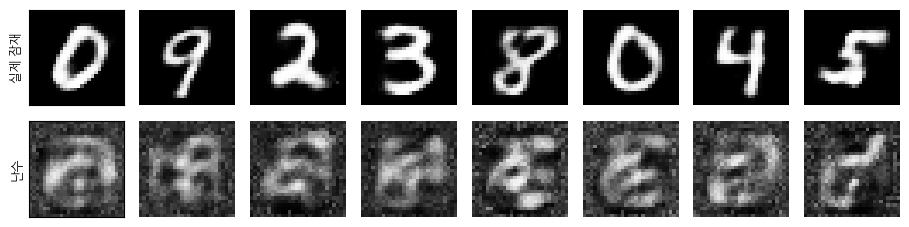


→ 실제 잠재 벡터를 넣으면 숫자가 나옵니다. **난수를 넣으면 얼룩입니다.**
→ 잠재 공간의 대부분이 **비어 있기** 때문입니다.
→ 생성을 하려면 **어디가 채워져 있는지**를 알아야 합니다. 그것이 14장입니다.


In [5]:
# 13장의 오토인코더로 「생성」을 해 봅니다. 디코더에 난수를 넣습니다.
enc, dec = train_autoencoder(x_train, LATENT)

Z = encode(enc, x_train[:5000])
print("학습 데이터가 실제로 만든 잠재 벡터의 분포 —")
print(f"  평균 {Z.mean():.3f}   표준편차 {Z.std():.3f}   0인 성분의 비율 {float((Z == 0).mean()):.3f}")
print()
print("★ **표준정규분포가 전혀 아닙니다.** ReLU라 음수가 없고, 평균이 7 넘습니다.")
print("  그런데 '생성'을 하려면 어떤 분포에서 뽑아야 하는지 알아야 합니다.")
print("  **오토인코더는 그것을 알려 주지 않습니다.**")
print()

rnd = np.random.default_rng(0).normal(size=(500, LATENT)).astype("float32")
gen_rand = decode(dec, rnd)
gen_real = decode(dec, Z[:500])

print(f"{'무엇을 디코더에 넣었나':<28}{'생성물끼리 평균 거리':>22}")
print("-" * 52)
print(f"{'표준정규분포 난수':<28}{diversity(gen_rand):>22.3f}")
print(f"{'실제 데이터의 잠재 벡터':<28}{diversity(gen_real):>22.3f}")
print(f"{'(진짜 숫자)':<28}{REAL_DIV:>22.3f}")
dlbook.record("ch14_ae_random_diversity", diversity(gen_rand))
dlbook.record("ch14_ae_real_diversity", diversity(gen_real))

show([gen_real[:8], gen_rand[:8]], ["실제 잠재", "난수"])

print()
print("→ 실제 잠재 벡터를 넣으면 숫자가 나옵니다. **난수를 넣으면 얼룩입니다.**")
print("→ 잠재 공간의 대부분이 **비어 있기** 때문입니다.")
print("→ 생성을 하려면 **어디가 채워져 있는지**를 알아야 합니다. 그것이 14장입니다.")

## 정리

| 디코더에 넣은 것 | 생성물끼리 평균 거리 |
|---|:--:|
| 표준정규분포 난수 | **11.16** |
| 실제 데이터의 잠재 벡터 | 18.59 |
| (진짜 숫자) | 20.29 |

- **실제 잠재 벡터를 넣으면 숫자가 나오고, 난수를 넣으면 얼룩이 나옵니다.**
- 학습된 잠재 벡터의 분포는 평균 7.5, 표준편차 6.8이고 **28%가 0**입니다.
  표준정규분포와 전혀 다릅니다.
- **오토인코더는 「어디가 채워져 있는지」를 알려 주지 않습니다.**
  그래서 생성 모델이 아닙니다.

> 이 문제를 푸는 길이 둘 있습니다.
> **① 잠재 분포를 알게 만든다** → VAE (15장 §15.5)
> **② 분포를 몰라도 되게 만든다** → **GAN (다음 노트북)**

### 연습

1. 잠재 벡터의 실제 분포에서 뽑아 보십시오(각 차원의 평균·표준편차 사용).
   난수보다 나아집니까.
2. 인코더의 마지막 활성화를 `relu` 대신 없애면 분포가 어떻게 됩니까.
3. 두 숫자의 잠재 벡터를 **직선으로 이어** 중간 점들을 디코딩하십시오.
   중간에 숫자가 아닌 것이 나옵니까.